In [1]:
from IQP_circuit import *
from MaxCut import *
from Partition import *
import jax
import json
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Gradient Variance

In [2]:
with open("maxcut.json", "r") as f:
    dataset_maxcut = json.load(f)

# Convert keys back to integers
dataset_maxcut = {int(k): v for k, v in dataset_maxcut.items()}

with open("ising.json", "r") as f:
    dataset_ising = json.load(f)

# Convert keys back to integers
dataset_ising = {int(k): v for k, v in dataset_ising.items()}

with open("partition.json", "r") as f:
    dataset_partition = json.load(f)

# Convert keys back to integers
dataset_partition = {int(k): v for k, v in dataset_partition.items()}

print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
def obs(n_qubits: int, corr: int = 1) -> np.array:
    
    obs = []
    
    for i in range(n_qubits):
        ob = [0]*n_qubits
        ob[i] = 1
        obs.append(ob)
        
    if corr == 2:
        for i in range(n_qubits):
            for j in range(i+1, n_qubits):
                ob = [0]*n_qubits
                ob[i] = 1
                ob[j] = 1
                obs.append(ob)
                
    return np.array(obs)

In [4]:
def uniform_sampler(key, n_params):

    return jax.random.uniform(
        key,
        shape=(n_params,),
        minval=0,
        maxval=jnp.pi,
    )

def normal_sampler(key, n_params):

    return jax.random.normal(
        key,
        shape=(n_params,),
    )

def pi4_sampler(key, n_params):

    return jnp.ones(n_params)*(jnp.pi/4) + 0.05*jax.random.normal(key, shape=(n_params,),)

In [5]:
def gradient_variance(
        circuit,
        ops,
        coeffs,
        init_sampler,
        n_samples=1000,
        n_trials=100,
):

    grad_fn = jax.grad(loss_fn)

    all_grads = []

    key = jax.random.PRNGKey(0)

    for k in range(n_trials):

        key, subkey1, subkey2 = jax.random.split(key, 3)

        params = init_sampler(subkey1, len(circuit.gates))

        grads = grad_fn(
            params,
            circuit,
            ops,
            coeffs,
            n_samples,
            subkey2,
        )

        all_grads.append(np.asarray(grads))

    all_grads = np.array(all_grads)

    # variance for each parameter
    var_per_param = np.var(all_grads, axis=0)

    # average variance
    avg_var = np.mean(var_per_param)

    return avg_var

In [6]:
qubits = [3, 6, 9, 12, 15, 18, 21]
n_problem = 50
n_samples = 1000
n_trials = 200
sampler = {'Uniform $(0,\pi)$': uniform_sampler, 'Normal $(0,1)$': normal_sampler, 'All $\pi/4$': pi4_sampler}
sampler_method = ['Uniform $(0,\pi)$', 'Normal $(0,1)$', 'All $\pi/4$']
modes = ['full', 'circular', 'single']
grad_vars_hamiltonians = {}
grad_fn = jax.grad(loss_fn)

In [7]:
grad_vars_hamiltonians['Classical Ising'] = {}

for method in sampler_method:
    grad_vars_hamiltonians['Classical Ising'][method] = {}

    for mode in modes:
        grad_vars_hamiltonians['Classical Ising'][method][mode] = {}

        for n_qubits in qubits:
            grad_vars = []

            for i in range(n_problem):
                coeffs = np.array(dataset_ising[n_qubits][i])
                ops = obs(n_qubits, 2)
                gates = gens(n_qubits, mode)
                circuit = iqp.IqpSimulator(n_qubits, gates)

                grad_vars.append(
                    gradient_variance(
                        circuit,
                        ops,
                        coeffs,
                        sampler[method],
                        n_samples,
                        n_trials,
                    )
                )

                print(method, mode, n_qubits, i)

            grad_vars_hamiltonians['Classical Ising'][method][mode][n_qubits] = grad_vars

Uniform $(0,\pi)$ full 3 0
Uniform $(0,\pi)$ full 3 1
Uniform $(0,\pi)$ full 3 2
Uniform $(0,\pi)$ full 3 3
Uniform $(0,\pi)$ full 3 4
Uniform $(0,\pi)$ full 3 5
Uniform $(0,\pi)$ full 3 6
Uniform $(0,\pi)$ full 3 7
Uniform $(0,\pi)$ full 3 8
Uniform $(0,\pi)$ full 3 9
Uniform $(0,\pi)$ full 3 10
Uniform $(0,\pi)$ full 3 11
Uniform $(0,\pi)$ full 3 12
Uniform $(0,\pi)$ full 3 13
Uniform $(0,\pi)$ full 3 14
Uniform $(0,\pi)$ full 3 15
Uniform $(0,\pi)$ full 3 16
Uniform $(0,\pi)$ full 3 17
Uniform $(0,\pi)$ full 3 18
Uniform $(0,\pi)$ full 3 19
Uniform $(0,\pi)$ full 3 20
Uniform $(0,\pi)$ full 3 21
Uniform $(0,\pi)$ full 3 22
Uniform $(0,\pi)$ full 3 23
Uniform $(0,\pi)$ full 3 24
Uniform $(0,\pi)$ full 3 25
Uniform $(0,\pi)$ full 3 26
Uniform $(0,\pi)$ full 3 27
Uniform $(0,\pi)$ full 3 28
Uniform $(0,\pi)$ full 3 29
Uniform $(0,\pi)$ full 3 30
Uniform $(0,\pi)$ full 3 31
Uniform $(0,\pi)$ full 3 32
Uniform $(0,\pi)$ full 3 33
Uniform $(0,\pi)$ full 3 34
Uniform $(0,\pi)$ full 3 35
Un

In [8]:
grad_vars_hamiltonians['Number Partition'] = {}

for method in sampler_method:
    grad_vars_hamiltonians['Number Partition'][method] = {}

    for mode in modes:
        grad_vars_hamiltonians['Number Partition'][method][mode] = {}

        for n_qubits in qubits:
            grad_vars = []

            for i in range(n_problem):
                numbers = dataset_partition[n_qubits][i]
                ops, coeffs = number_partition_obs(numbers)
                gates = gens(n_qubits, mode)
                circuit = iqp.IqpSimulator(n_qubits, gates)

                grad_vars.append(
                    gradient_variance(
                        circuit,
                        ops,
                        coeffs,
                        sampler[method],
                        n_samples,
                        n_trials,
                    )
                )

                print(method, mode, n_qubits, i)

            grad_vars_hamiltonians['Number Partition'][method][mode][n_qubits] = grad_vars

Uniform $(0,\pi)$ full 3 0
Uniform $(0,\pi)$ full 3 1
Uniform $(0,\pi)$ full 3 2
Uniform $(0,\pi)$ full 3 3
Uniform $(0,\pi)$ full 3 4
Uniform $(0,\pi)$ full 3 5
Uniform $(0,\pi)$ full 3 6
Uniform $(0,\pi)$ full 3 7
Uniform $(0,\pi)$ full 3 8
Uniform $(0,\pi)$ full 3 9
Uniform $(0,\pi)$ full 3 10
Uniform $(0,\pi)$ full 3 11
Uniform $(0,\pi)$ full 3 12
Uniform $(0,\pi)$ full 3 13
Uniform $(0,\pi)$ full 3 14
Uniform $(0,\pi)$ full 3 15
Uniform $(0,\pi)$ full 3 16
Uniform $(0,\pi)$ full 3 17
Uniform $(0,\pi)$ full 3 18
Uniform $(0,\pi)$ full 3 19
Uniform $(0,\pi)$ full 3 20
Uniform $(0,\pi)$ full 3 21
Uniform $(0,\pi)$ full 3 22
Uniform $(0,\pi)$ full 3 23
Uniform $(0,\pi)$ full 3 24
Uniform $(0,\pi)$ full 3 25
Uniform $(0,\pi)$ full 3 26
Uniform $(0,\pi)$ full 3 27
Uniform $(0,\pi)$ full 3 28
Uniform $(0,\pi)$ full 3 29
Uniform $(0,\pi)$ full 3 30
Uniform $(0,\pi)$ full 3 31
Uniform $(0,\pi)$ full 3 32
Uniform $(0,\pi)$ full 3 33
Uniform $(0,\pi)$ full 3 34
Uniform $(0,\pi)$ full 3 35
Un

In [9]:
grad_vars_hamiltonians['MaxCut'] = {}

for method in sampler_method:
    grad_vars_hamiltonians['MaxCut'][method] = {}

    for mode in modes:
        grad_vars_hamiltonians['MaxCut'][method][mode] = {}

        for n_qubits in qubits:
            grad_vars = []

            for i in range(n_problem):
                edges, weights = dataset_maxcut[n_qubits][i]
                ops, coeffs = maxcut_obs(n_qubits, edges, weights)
                gates = gens(n_qubits, mode)
                circuit = iqp.IqpSimulator(n_qubits, gates)

                grad_vars.append(
                    gradient_variance(
                        circuit,
                        ops,
                        coeffs,
                        sampler[method],
                        n_samples,
                        n_trials,
                    )
                )

                print(method, mode, n_qubits, i)

            grad_vars_hamiltonians['MaxCut'][method][mode][n_qubits] = grad_vars

Uniform $(0,\pi)$ full 3 0
Uniform $(0,\pi)$ full 3 1
Uniform $(0,\pi)$ full 3 2
Uniform $(0,\pi)$ full 3 3
Uniform $(0,\pi)$ full 3 4
Uniform $(0,\pi)$ full 3 5
Uniform $(0,\pi)$ full 3 6
Uniform $(0,\pi)$ full 3 7
Uniform $(0,\pi)$ full 3 8
Uniform $(0,\pi)$ full 3 9
Uniform $(0,\pi)$ full 3 10
Uniform $(0,\pi)$ full 3 11
Uniform $(0,\pi)$ full 3 12
Uniform $(0,\pi)$ full 3 13
Uniform $(0,\pi)$ full 3 14
Uniform $(0,\pi)$ full 3 15
Uniform $(0,\pi)$ full 3 16
Uniform $(0,\pi)$ full 3 17
Uniform $(0,\pi)$ full 3 18
Uniform $(0,\pi)$ full 3 19
Uniform $(0,\pi)$ full 3 20
Uniform $(0,\pi)$ full 3 21
Uniform $(0,\pi)$ full 3 22
Uniform $(0,\pi)$ full 3 23
Uniform $(0,\pi)$ full 3 24
Uniform $(0,\pi)$ full 3 25
Uniform $(0,\pi)$ full 3 26
Uniform $(0,\pi)$ full 3 27
Uniform $(0,\pi)$ full 3 28
Uniform $(0,\pi)$ full 3 29
Uniform $(0,\pi)$ full 3 30
Uniform $(0,\pi)$ full 3 31
Uniform $(0,\pi)$ full 3 32
Uniform $(0,\pi)$ full 3 33
Uniform $(0,\pi)$ full 3 34
Uniform $(0,\pi)$ full 3 35
Un

In [10]:
# Save dataset to disk
with open("gradient_variance.json", "w") as f:
    json.dump(grad_vars_hamiltonians, f, indent=4)

print("Dataset saved to gradient_variance.json")

Dataset saved to gradient_variance.json


In [ ]:
# qubits = [3, 6, 9, 12, 15, 18, 21]

# grad_vars = []

# for n in qubits:

#     gates = gens(n, mode="full")

#     circuit = iqp.IqpSimulator(n, gates)

#     edges, weights = dataset[n][0]
#     ops, coeffs = maxcut_obs(n, edges, weights)

#     var = gradient_variance(
#         circuit,
#         ops,
#         coeffs,
#         uniform_sampler,
#         n_trials=200,
#     )

#     grad_vars.append(var)

In [ ]:
# plt.plot(qubits, grad_vars, 'o-')
# plt.xlabel("Number of qubits")
# plt.ylabel("Gradient variance")

In [ ]:
# import numpy as np

# # Collect every variance value in the whole dataset
# all_values = []

# for ham in grad_vars_hamiltonians:
#     for sampler in grad_vars_hamiltonians[ham]:
#         for mode in grad_vars_hamiltonians[ham][sampler]:
#             for nq in grad_vars_hamiltonians[ham][sampler][mode]:
#                 all_values.extend(
#                     grad_vars_hamiltonians[ham][sampler][mode][nq]
#                 )

# all_values = np.array(all_values)

# # Global scale
# global_max = np.max(all_values)
# global_mean = np.mean(all_values)
# global_std = np.std(all_values)

# print("Global max =", global_max)
# print("Global mean =", global_mean)

In [ ]:
# grad_vars_scaled = {}

# for ham in grad_vars_hamiltonians:
#     grad_vars_scaled[ham] = {}

#     for sampler in grad_vars_hamiltonians[ham]:
#         grad_vars_scaled[ham][sampler] = {}

#         for mode in grad_vars_hamiltonians[ham][sampler]:
#             grad_vars_scaled[ham][sampler][mode] = {}

#             for nq in grad_vars_hamiltonians[ham][sampler][mode]:

#                 values = np.array(
#                     grad_vars_hamiltonians[ham][sampler][mode][nq]
#                 )

#                 grad_vars_scaled[ham][sampler][mode][nq] = (
#                     values / global_max
#                 )

In [7]:
with open("gradient_variance.json", "r") as f:
    grad_vars_hamiltonians = json.load(f)

print("Dataset loaded successfully")

# with open("gradient_variance.json", "r") as f:
#     grad_vars_hamiltonians = json.load(f)

Dataset loaded successfully


In [8]:
import numpy as np

ham_scales = {}

for ham in grad_vars_hamiltonians:

    all_values = []

    for sampler in grad_vars_hamiltonians[ham]:
        for mode in grad_vars_hamiltonians[ham][sampler]:
            for nq in grad_vars_hamiltonians[ham][sampler][mode]:

                all_values.extend(
                    grad_vars_hamiltonians[ham][sampler][mode][nq]
                )

    ham_scales[ham] = np.max(all_values)

print(ham_scales)

grad_vars_scaled = {}

for ham in grad_vars_hamiltonians:

    scale = ham_scales[ham]
    grad_vars_scaled[ham] = {}

    for sampler in grad_vars_hamiltonians[ham]:
        grad_vars_scaled[ham][sampler] = {}

        for mode in grad_vars_hamiltonians[ham][sampler]:
            grad_vars_scaled[ham][sampler][mode] = {}

            for nq in grad_vars_hamiltonians[ham][sampler][mode]:

                values = np.array(
                    grad_vars_hamiltonians[ham][sampler][mode][nq]
                )

                grad_vars_scaled[ham][sampler][mode][nq] = values / scale

{'Classical Ising': np.float64(14.803471530594814), 'Number Partition': np.float64(2442664645.9057364), 'MaxCut': np.float64(50.92493288069135)}


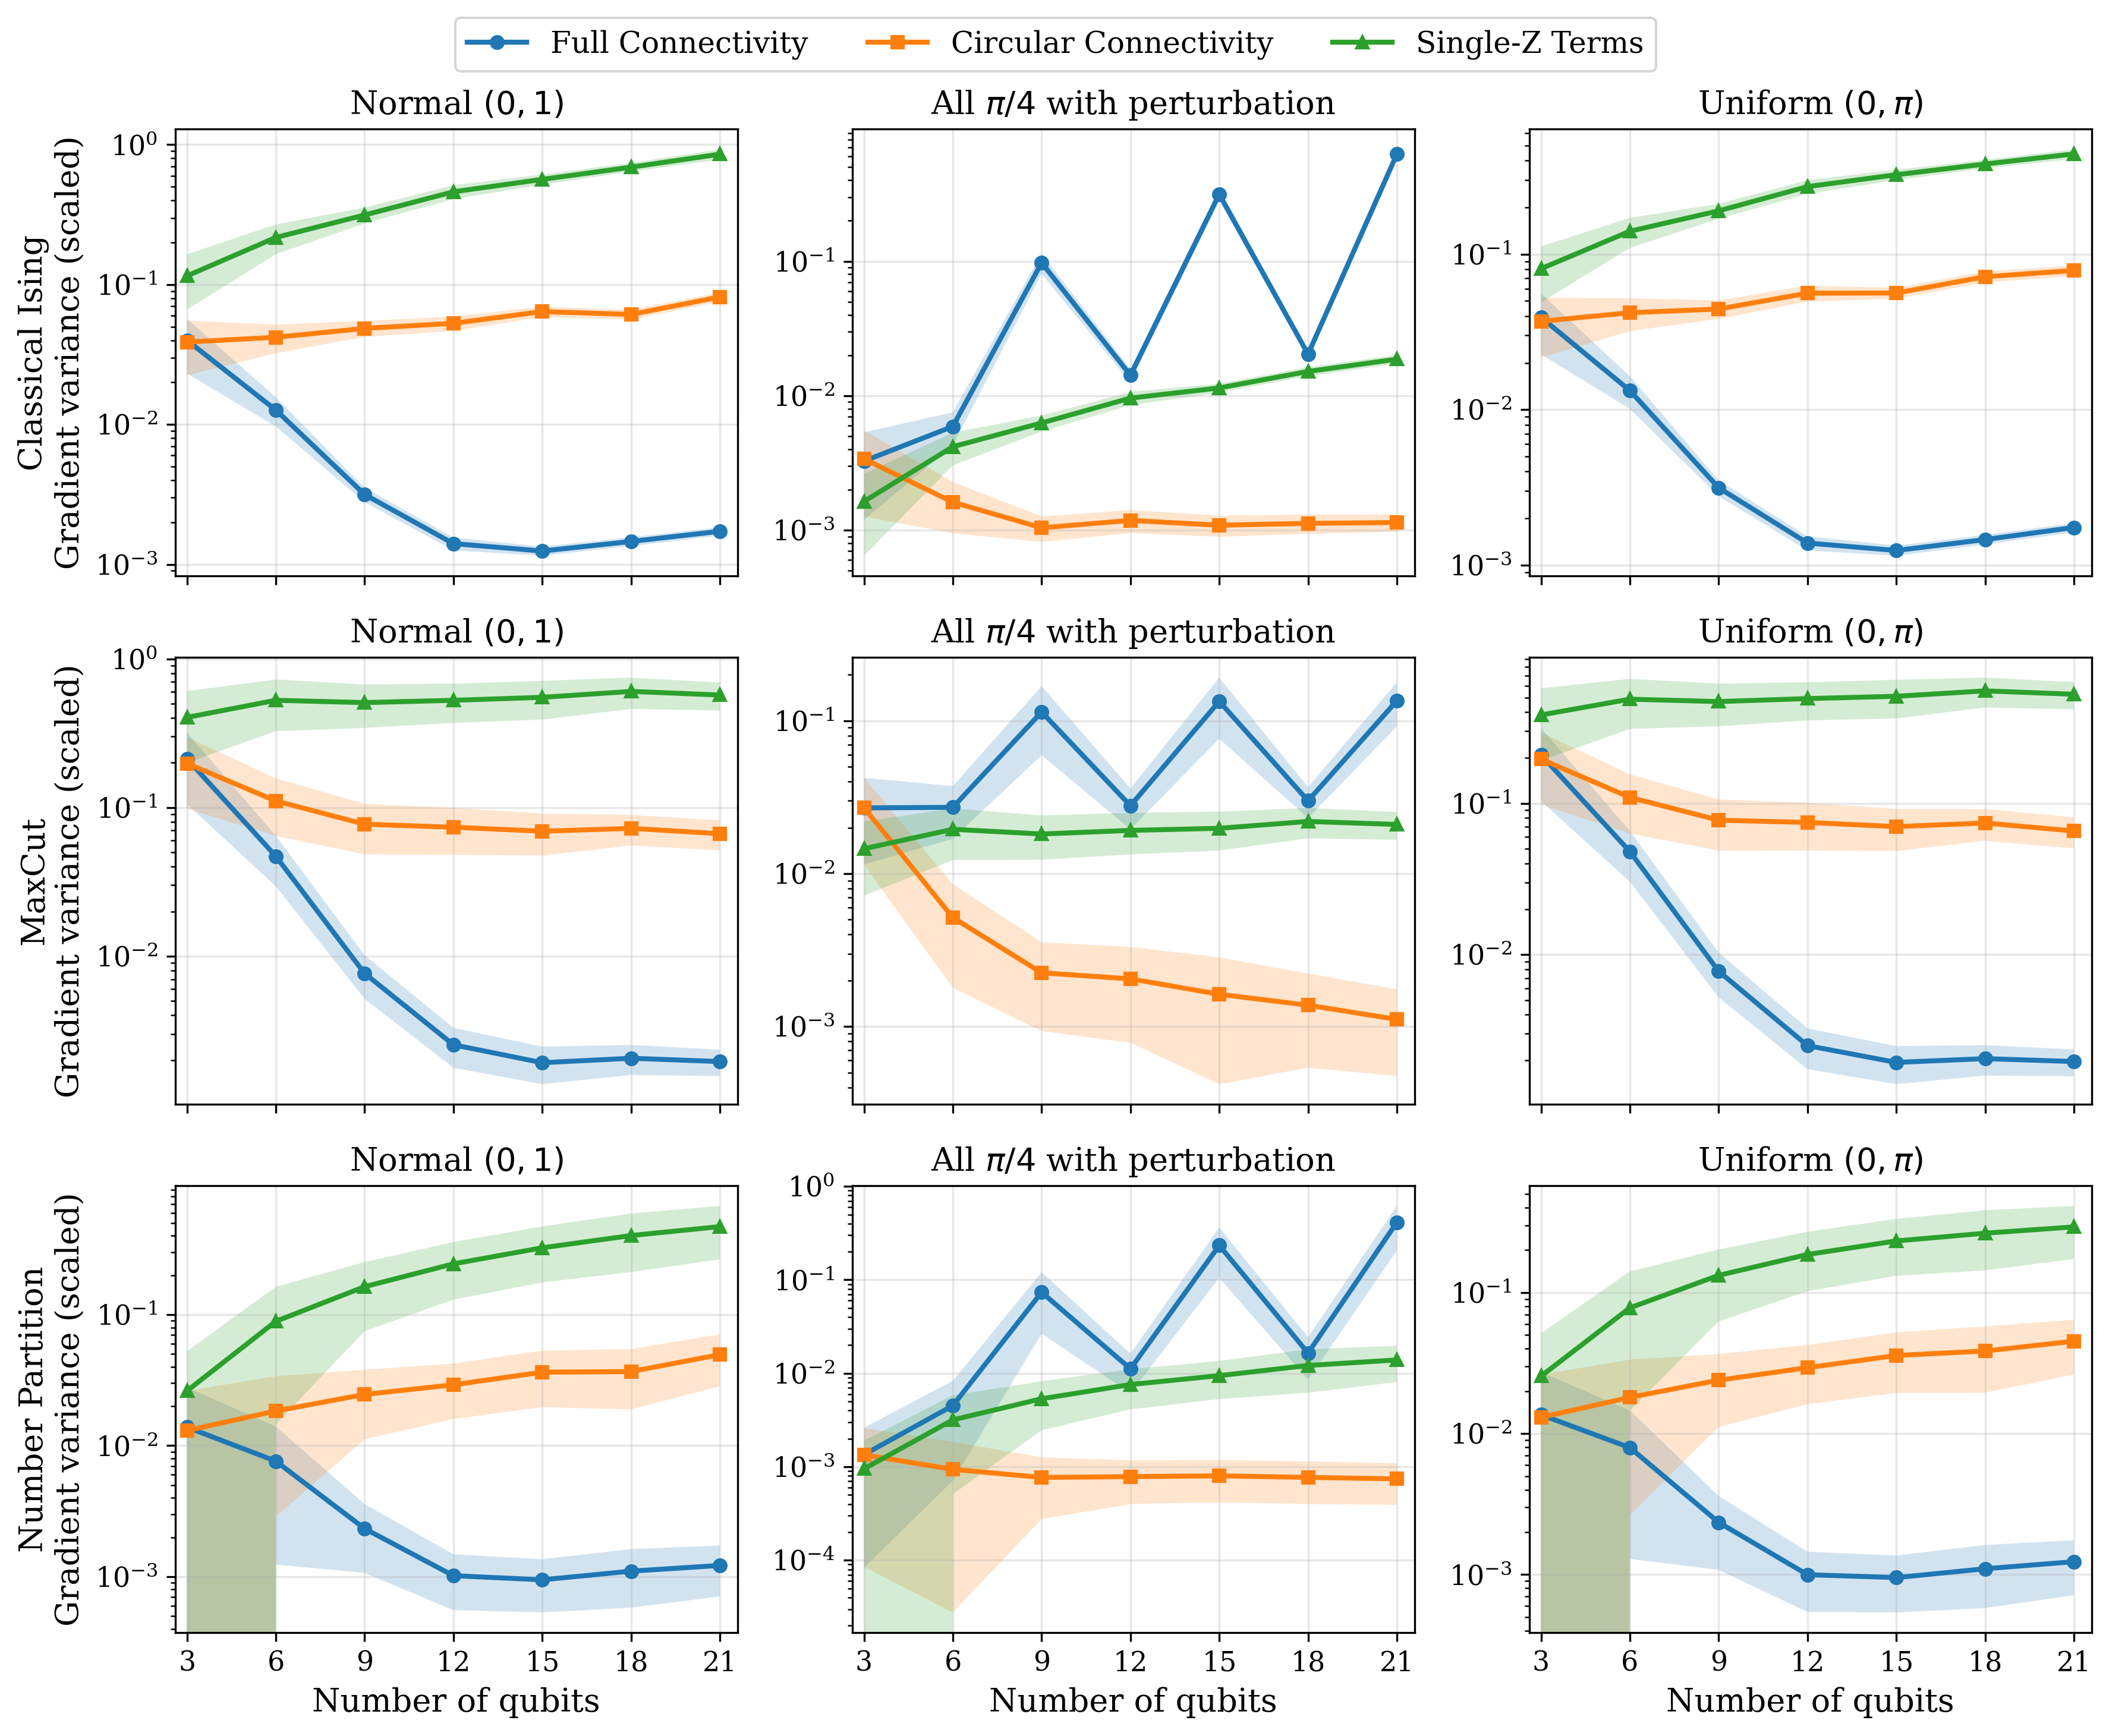

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Order of rows and columns
hamiltonians = ['Classical Ising', 'MaxCut', 'Number Partition']
sampler_method = ['Normal $(0,1)$', 'All $\pi/4$', 'Uniform $(0,\pi)$']
sampler_title = {'Normal $(0,1)$': 'Normal $(0,1)$', 'All $\pi/4$': 'All $\pi/4$ with perturbation', 'Uniform $(0,\pi)$': 'Uniform $(0,\pi)$'}
modes = ['full', 'circular', 'single']
qubits = ['3', '6', '9', '12', '15', '18', '21']
qubits_index =  [3, 6, 9, 12, 15, 18, 21]

# Labels and styles
mode_labels = {
    'full': 'Full Connectivity',
    'circular': 'Circular Connectivity',
    'single': 'Single-Z Terms'
}

mode_styles = {
    'full': '-o',
    'circular': '-s',
    'single': '-^'
}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
})

fig, axes = plt.subplots(
    nrows=len(hamiltonians),
    ncols=len(sampler_method),
    figsize=(12, 10),
    sharex=True,
    # sharey=True
)

for i, ham in enumerate(hamiltonians):
    for j, sampler in enumerate(sampler_method):

        ax = axes[i, j]

        for mode in modes:

            means = []
            stds = []

            for nq in qubits:

                # List of variances over all problems/trials
                values = np.array(
                    grad_vars_scaled[ham][sampler][mode][nq]
                )

                means.append(np.mean(values))
                stds.append(np.std(values))

            means = np.array(means)
            stds = np.array(stds)

            # Plot mean
            ax.plot(
                qubits_index,
                means,
                mode_styles[mode],
                linewidth=2,
                markersize=5,
                label=mode_labels[mode]
            )

            # Error band
            ax.fill_between(
                qubits_index,
                means - stds,
                means + stds,
                alpha=0.2
            )

        # Titles
        ax.set_title(f'{sampler_title[sampler]}')
        ax.set_xlim(2.6, 21.6)
        ax.set_xticks(np.arange(3, 22, 3))

        # Log scale is usually better for gradient variance
        ax.set_yscale('log')

        ax.grid(True, alpha=0.3)

        if i == len(hamiltonians)-1:
            ax.set_xlabel('Number of qubits')

        if j == 0:
            ax.set_ylabel(ham + '\nGradient variance (scaled)')

# One legend for all subplots
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=3,
    fontsize=12,
    bbox_to_anchor=(0.5, 0.98)
)

# fig.suptitle(
#     'Comparison of different Hamiltonians with different Initializations \n (1000 iterations, 50 problem samples, and 1000 Monte Carlo sampling for each configuration)',
#     fontsize=16,
#     y=0.98
# )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(
    "IQP_gradient_variance.pdf",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

# Expressibility

In [24]:
import pennylane as qp
import numpy as np

def build_iqp_state_circuit(gates, n_qubits):

    dev = qp.device("default.qubit", wires=n_qubits)

    @qp.qnode(dev)
    def circuit(params):

        # |+>^n
        for i in range(n_qubits):
            qp.Hadamard(i)

        for theta, gate in zip(params, gates):

            term = gate[0]

            # single-Z term
            if len(term) == 1:
                qp.RZ(theta, wires=term[0])

            # Z^{n} term
            elif len(term) >= 2:
                qp.MultiRZ(theta, wires=term)

        # back to basis
        for i in range(n_qubits):
            qp.Hadamard(i)

        return qp.state()

    return circuit

In [25]:
def random_states(gates, n_qubits, n_states=1000):

    circuit = build_iqp_state_circuit(gates, n_qubits)

    states = []

    for _ in range(n_states):

        theta = np.random.uniform(0, np.pi, len(gates))

        states.append(circuit(theta))

    return np.array(states)

In [26]:
def fidelity_distribution(states):

    n_states = len(states)

    fidelities = []

    for i in range(n_states):

        for j in range(i+1, n_states):

            F = np.abs(np.vdot(states[i], states[j]))**2

            fidelities.append(F)

    return np.array(fidelities)

In [27]:
# from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon


def expressibility(gates, n_qubits, n_states=1000, bins=150):

    states = random_states(gates, n_qubits, n_states)

    fidelities = fidelity_distribution(states)

    hist, bins_ = np.histogram(fidelities, bins=bins, density=True)

    centers = (bins_[:-1]+bins_[1:])/2

    d = 2**n_qubits

    haar_pdf = (d-1)*(1-centers)**(d-2)

    hist /= np.sum(hist)
    haar_pdf /= np.sum(haar_pdf)

    return jensenshannon(hist+1e-12, haar_pdf+1e-12)

In [6]:
# qubits = [3, 6, 9, 12, 15, 18, 21]
qubits = range(2, 19)

expr_full = []
expr_circular = []
expr_single = []

for n in qubits:
    print(n)
    expr_full.append(expressibility(gens(n, "full"), n))
    print('Full, done')
    expr_circular.append(expressibility(gens(n, "circular"), n))
    print('Circular, done')
    expr_single.append(expressibility(gens(n, "single"), n))
    print('Single, done')

2
Full, done
Circular, done
Single, done
3
Full, done
Circular, done
Single, done
4
Full, done
Circular, done
Single, done
5
Full, done
Circular, done
Single, done
6
Full, done
Circular, done
Single, done
7
Full, done
Circular, done
Single, done
8
Full, done
Circular, done
Single, done
9
Full, done
Circular, done
Single, done
10
Full, done
Circular, done
Single, done
11
Full, done
Circular, done
Single, done
12
Full, done
Circular, done
Single, done
13
Full, done
Circular, done
Single, done
14
Full, done
Circular, done
Single, done
15
Full, done
Circular, done
Single, done
16
Full, done
Circular, done
Single, done
17
Full, done
Circular, done
Single, done
18
Full, done
Circular, done
Single, done


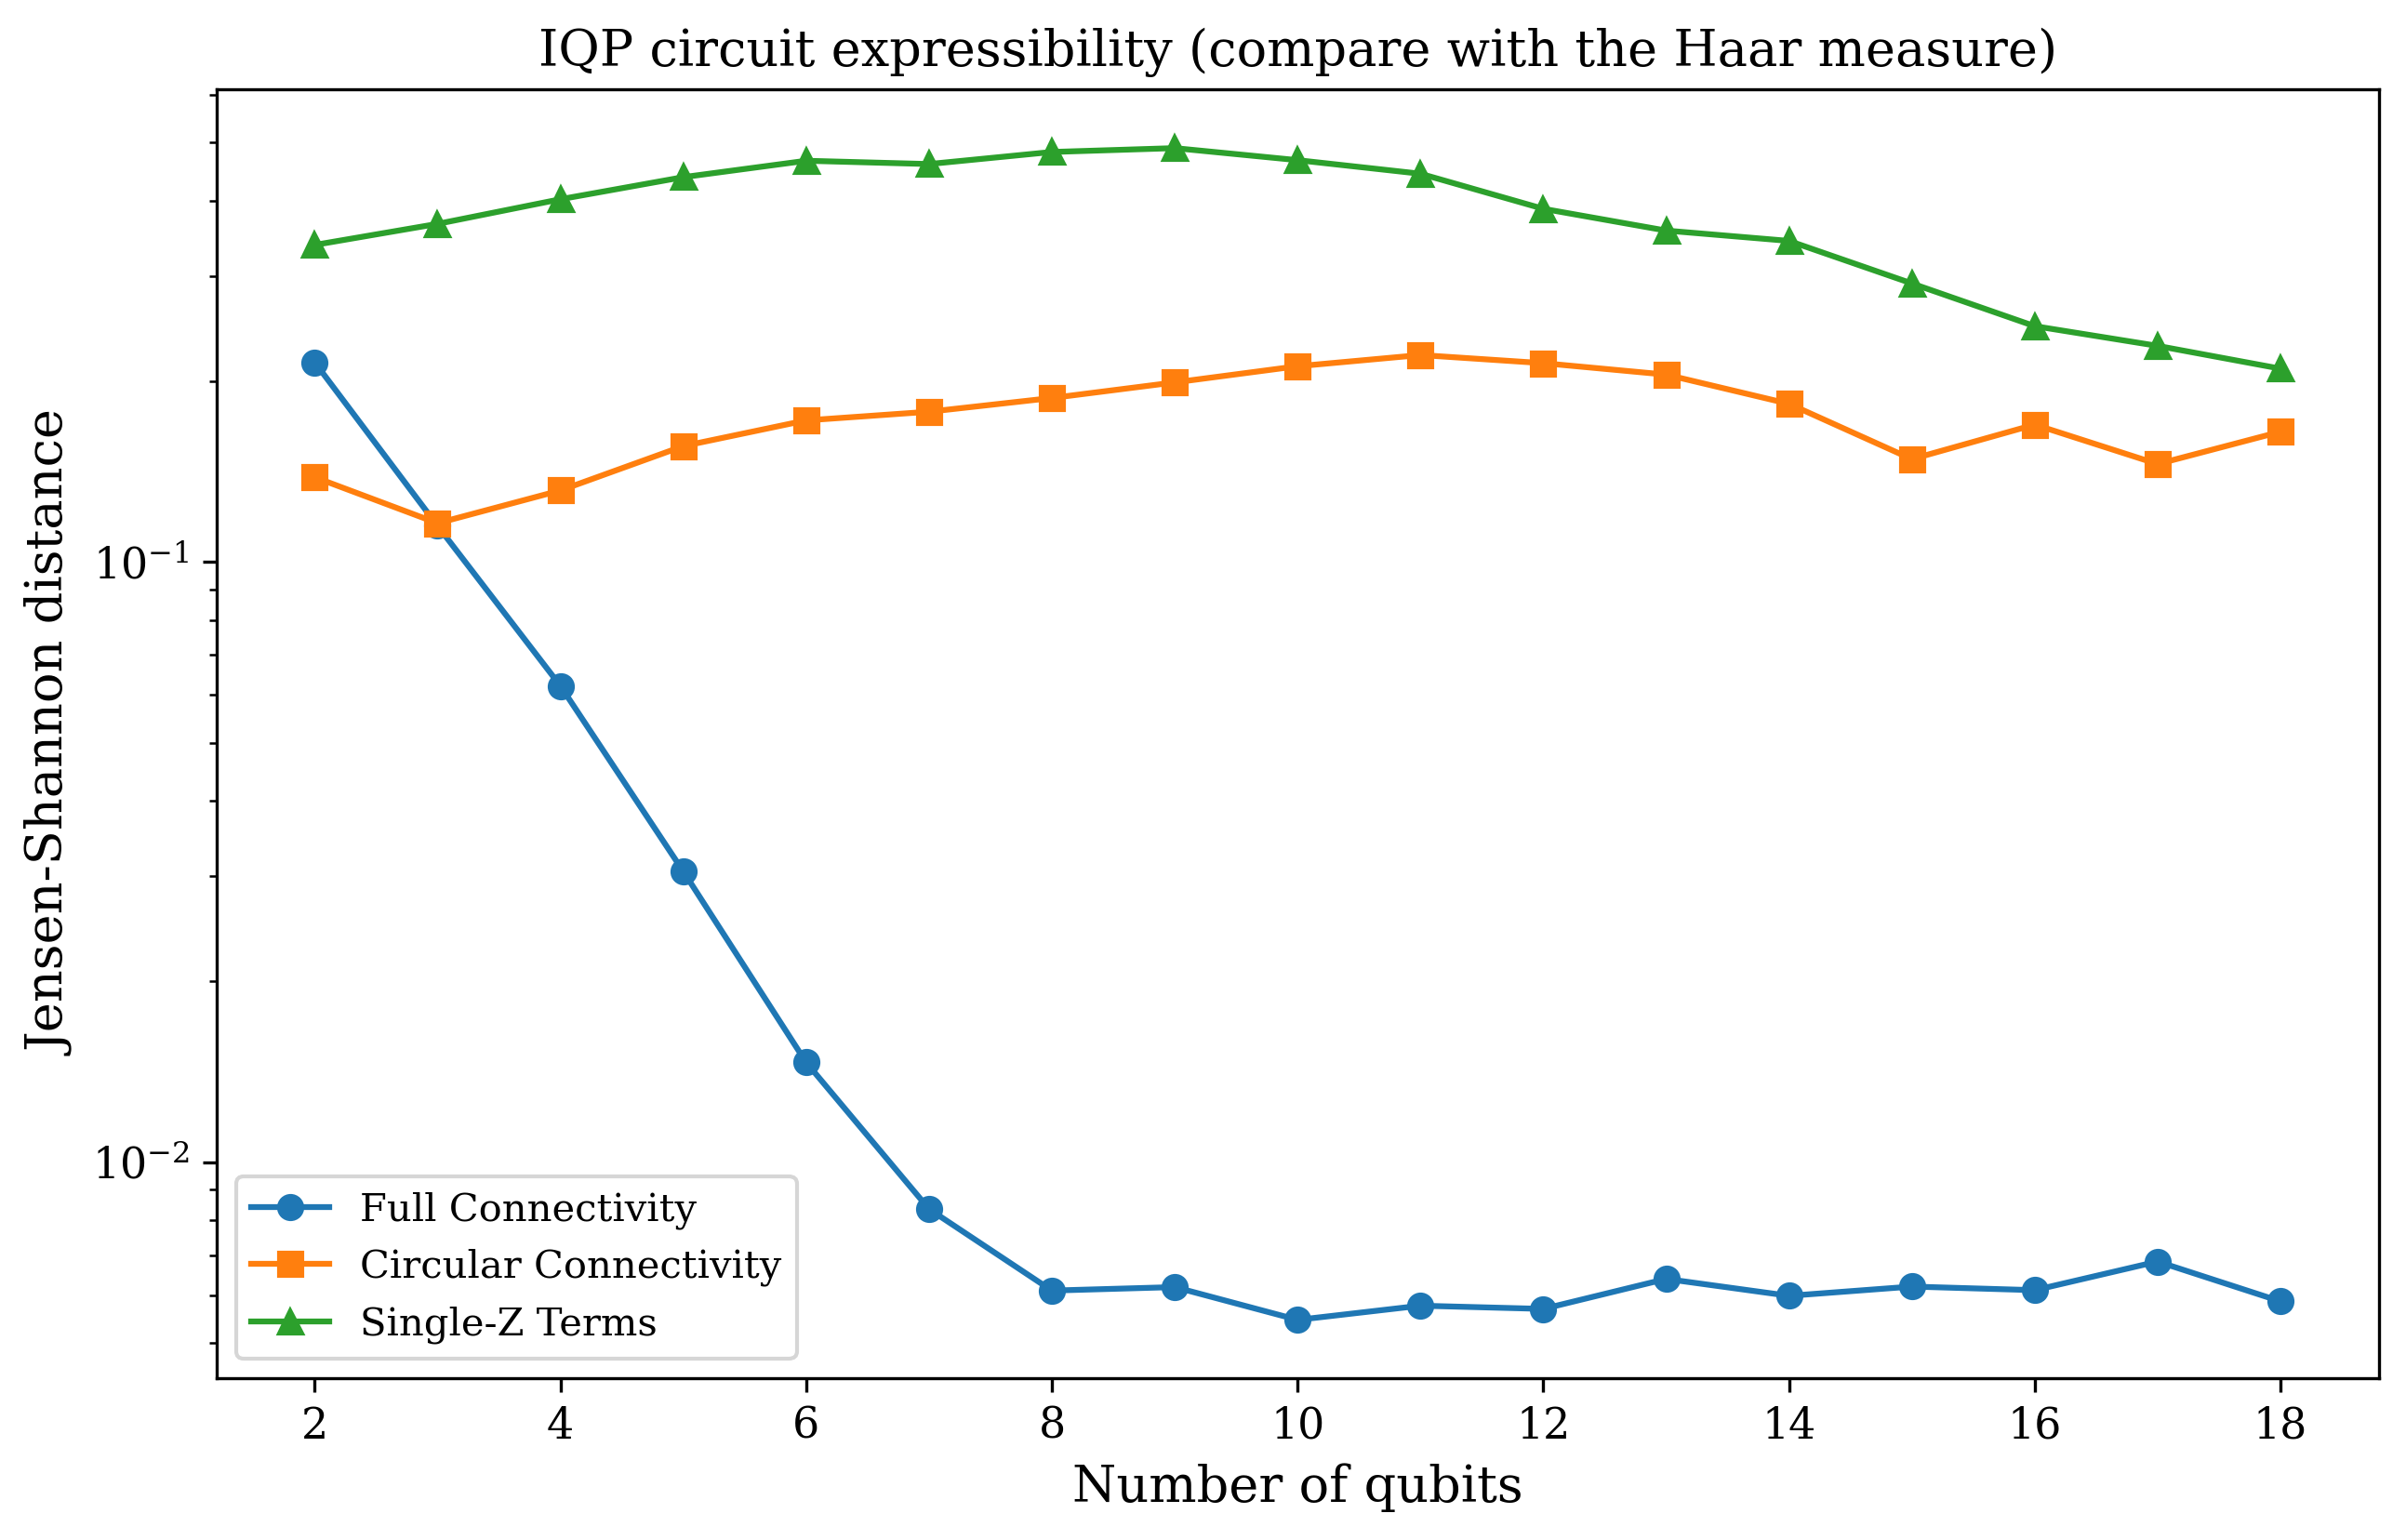

In [7]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
})

plt.figure(figsize=(10, 6))

plt.semilogy(qubits, expr_full, 'o-', label='Full Connectivity')
plt.semilogy(qubits, expr_circular, 's-', label='Circular Connectivity')
plt.semilogy(qubits, expr_single, '^-',label='Single-Z Terms')

plt.xlabel("Number of qubits")
plt.ylabel("Jensen-Shannon distance")
plt.title('IQP circuit expressibility (compare with the Haar measure)')
plt.legend()

plt.savefig(
    "IQP_expressibility.png",
    dpi=600,
    bbox_inches="tight"
)

In [8]:
expr = {
        'full': expr_full,
        'circular': expr_circular,
        'single': expr_single
       }

In [9]:
# Save dataset to disk
with open("expressibility.json", "w") as f:
    json.dump(expr, f, indent=4)

print("Dataset saved to expressibility.json")

Dataset saved to expressibility.json


In [28]:
with open("expressibility.json", "r") as f:
    expr = json.load(f)

print("Dataset loaded successfully")

Dataset loaded successfully


In [29]:
expr

{'full': [0.21519798008731975,
  0.1148899912210326,
  0.0621520006213909,
  0.030506325846765978,
  0.014657209257768658,
  0.00834991892855991,
  0.006106016715781021,
  0.006188505405158249,
  0.005457070409428758,
  0.005762118522937927,
  0.0056912547376545865,
  0.006385370111486155,
  0.005984867740421462,
  0.006200889545599032,
  0.006115537787345064,
  0.00682640068760116,
  0.005858603805434431],
 'circular': [0.1384699529327598,
  0.11606193559195485,
  0.1316221830831977,
  0.15603571467426475,
  0.17221935690821508,
  0.17803863011311266,
  0.18767111790450186,
  0.19924752172033575,
  0.2119999254376438,
  0.2213081637574082,
  0.2145080785863654,
  0.2052770151235115,
  0.18351129053161536,
  0.14841641901598518,
  0.16945054699563541,
  0.14565426749099916,
  0.1648685104565472],
 'single': [0.33767269592704685,
  0.366098949986451,
  0.4023876103325441,
  0.43798411495390344,
  0.466438117001513,
  0.46056607338193445,
  0.4824212883258477,
  0.4896000901699844,
  0.4

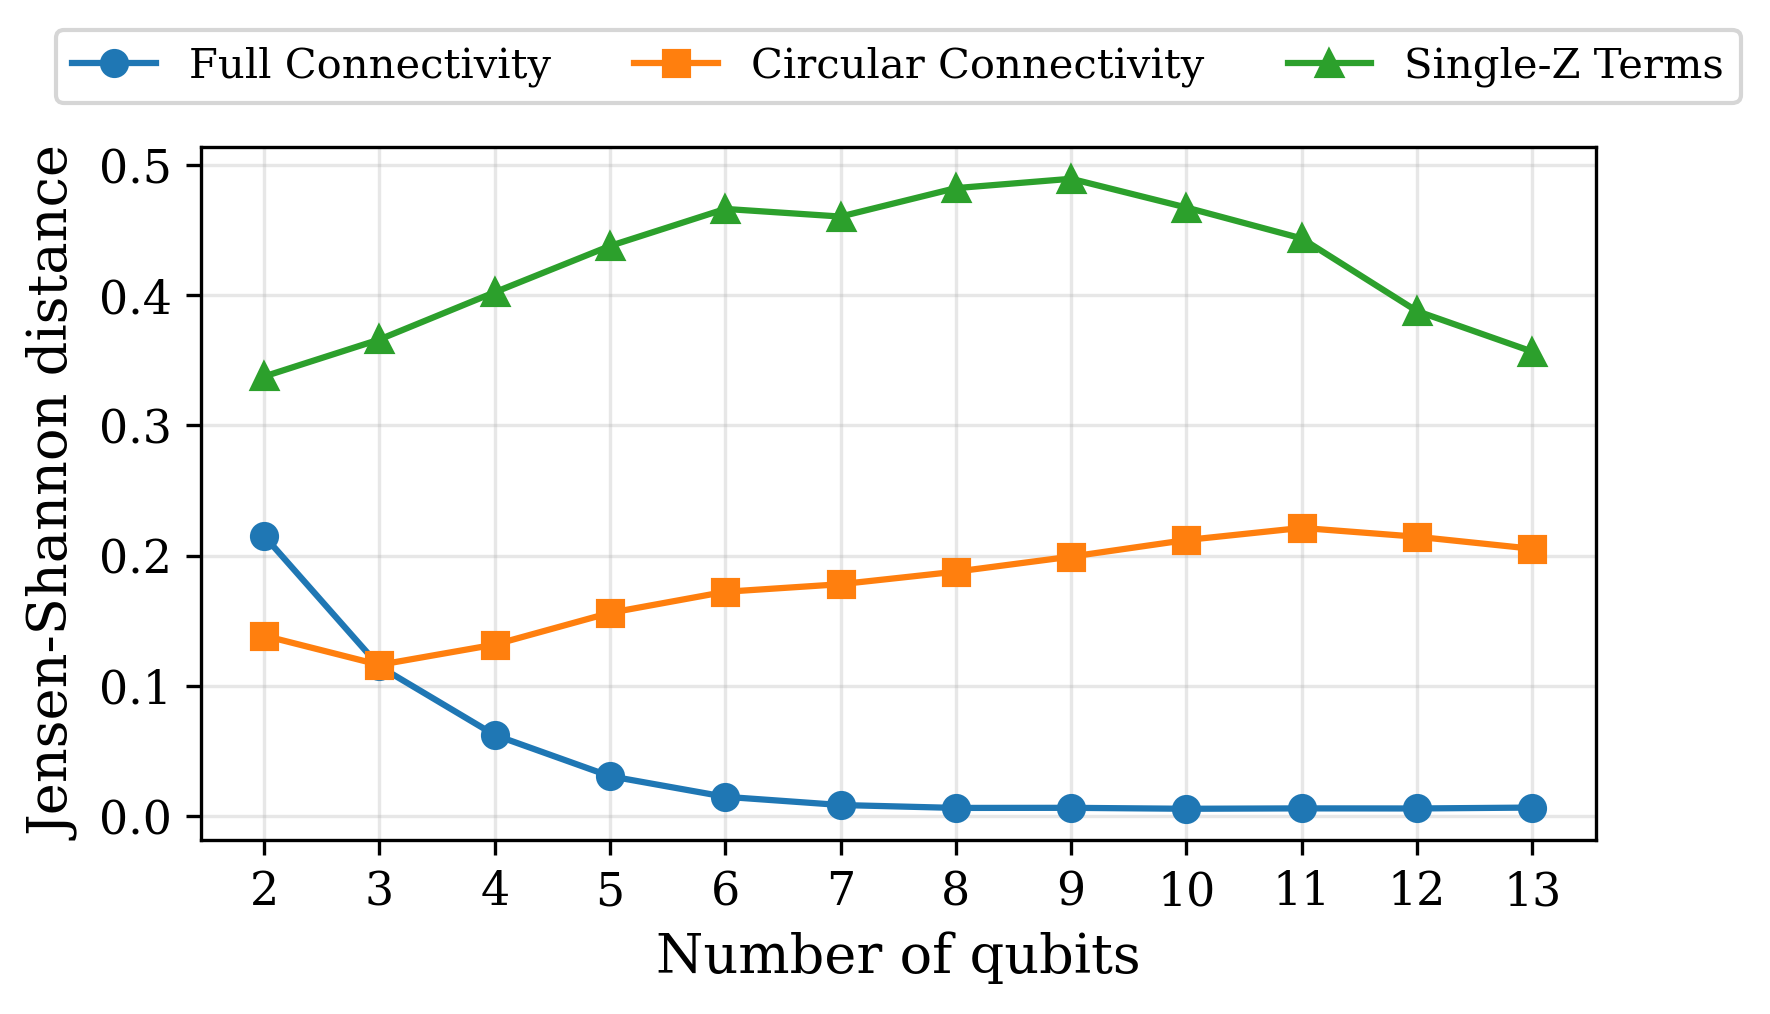

In [55]:
qubits = range(2, 14)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
})

plt.figure(figsize=(6, 3))

plt.plot(qubits, expr['full'][:len(qubits)], 'o-', label='Full Connectivity')
plt.plot(qubits, expr['circular'][:len(qubits)], 's-', label='Circular Connectivity')
plt.plot(qubits, expr['single'][:len(qubits)], '^-',label='Single-Z Terms')

plt.xlabel("Number of qubits")
plt.ylabel("Jensen-Shannon distance")
plt.xticks(np.arange(2, 14, 1))
# plt.title('IQP circuit expressibility (compare with the Haar measure)')
plt.grid(True, alpha=0.3)
# plt.legend()
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.2),
    ncol=3,
    frameon=True
)

plt.savefig(
    "IQP_expressibility.pdf",
    dpi=600,
    bbox_inches="tight"
)

# Entanglement Entropy

In [31]:
import pennylane as qp
import pennylane.numpy as np

def build_state_circuit(gates, n_qubits):

    dev = qp.device("default.qubit", wires=n_qubits)

    @qp.qnode(dev)
    def state_circuit(params):

        # |+>^n
        for i in range(n_qubits):
            qp.Hadamard(i)

        # IQP gates
        for theta, gate in zip(params, gates):

            term = gate[0]

            if len(term) == 1:
                qp.RZ(theta, wires=term[0])

            elif len(term) >= 2:
                qp.MultiRZ(theta, wires=term)

        # back to basis
        for i in range(n_qubits):
            qp.Hadamard(i)

        return qp.state()

    return state_circuit

In [32]:
def entanglement_entropy(state, n_qubits):

    rho = qp.math.dm_from_state_vector(state)
    cut = n_qubits // 2
    wires_A = list(range(cut))
    S = qp.math.vn_entropy(rho, indices=wires_A, base=2)

    return float(S)

In [33]:
def compute_average_entropy(gates, n_qubits, n_states=1000, init='uniform'):

    state_circuit = build_state_circuit(gates, n_qubits)
    n_params = len(gates)
    entropies = []

    for _ in range(n_states):

        if init == 'uniform':
            theta = np.random.uniform(0, np.pi, n_params)

        elif init == 'normal':

            theta = np.random.normal(0, 1, n_params)

        elif init == 'pi4':
            theta = (np.pi/4 + 0.05*np.random.normal(0, 1, n_params))

        state = state_circuit(theta)
        S = entanglement_entropy(state, n_qubits)
        entropies.append(S)

    return (np.mean(entropies), np.std(entropies))

In [5]:
qubits = range(2, 14)

S_full = []
S_circular = []
S_single = []

for n in qubits:

    gates_full = gens(n, "full")
    gates_circular = gens(n, "circular")
    gates_single = gens(n, "single")
    
    print(n)
    
    mean_S, _ = compute_average_entropy(gates_full, n, n_states=1000)
    S_full.append(mean_S)

    print("full, done")

    mean_S, _ = compute_average_entropy(gates_circular, n, n_states=1000)
    S_circular.append(mean_S)

    print("circular, done")

    mean_S, _ = compute_average_entropy(gates_single, n, n_states=1000)
    S_single.append(mean_S)

    print("single, done")

2
full, done
circular, done
single, done
3
full, done
circular, done
single, done
4
full, done
circular, done
single, done
5
full, done
circular, done
single, done
6
full, done
circular, done
single, done
7
full, done
circular, done
single, done
8
full, done
circular, done
single, done
9
full, done
circular, done
single, done
10
full, done
circular, done
single, done
11
full, done
circular, done
single, done
12
full, done
circular, done
single, done
13
full, done
circular, done
single, done


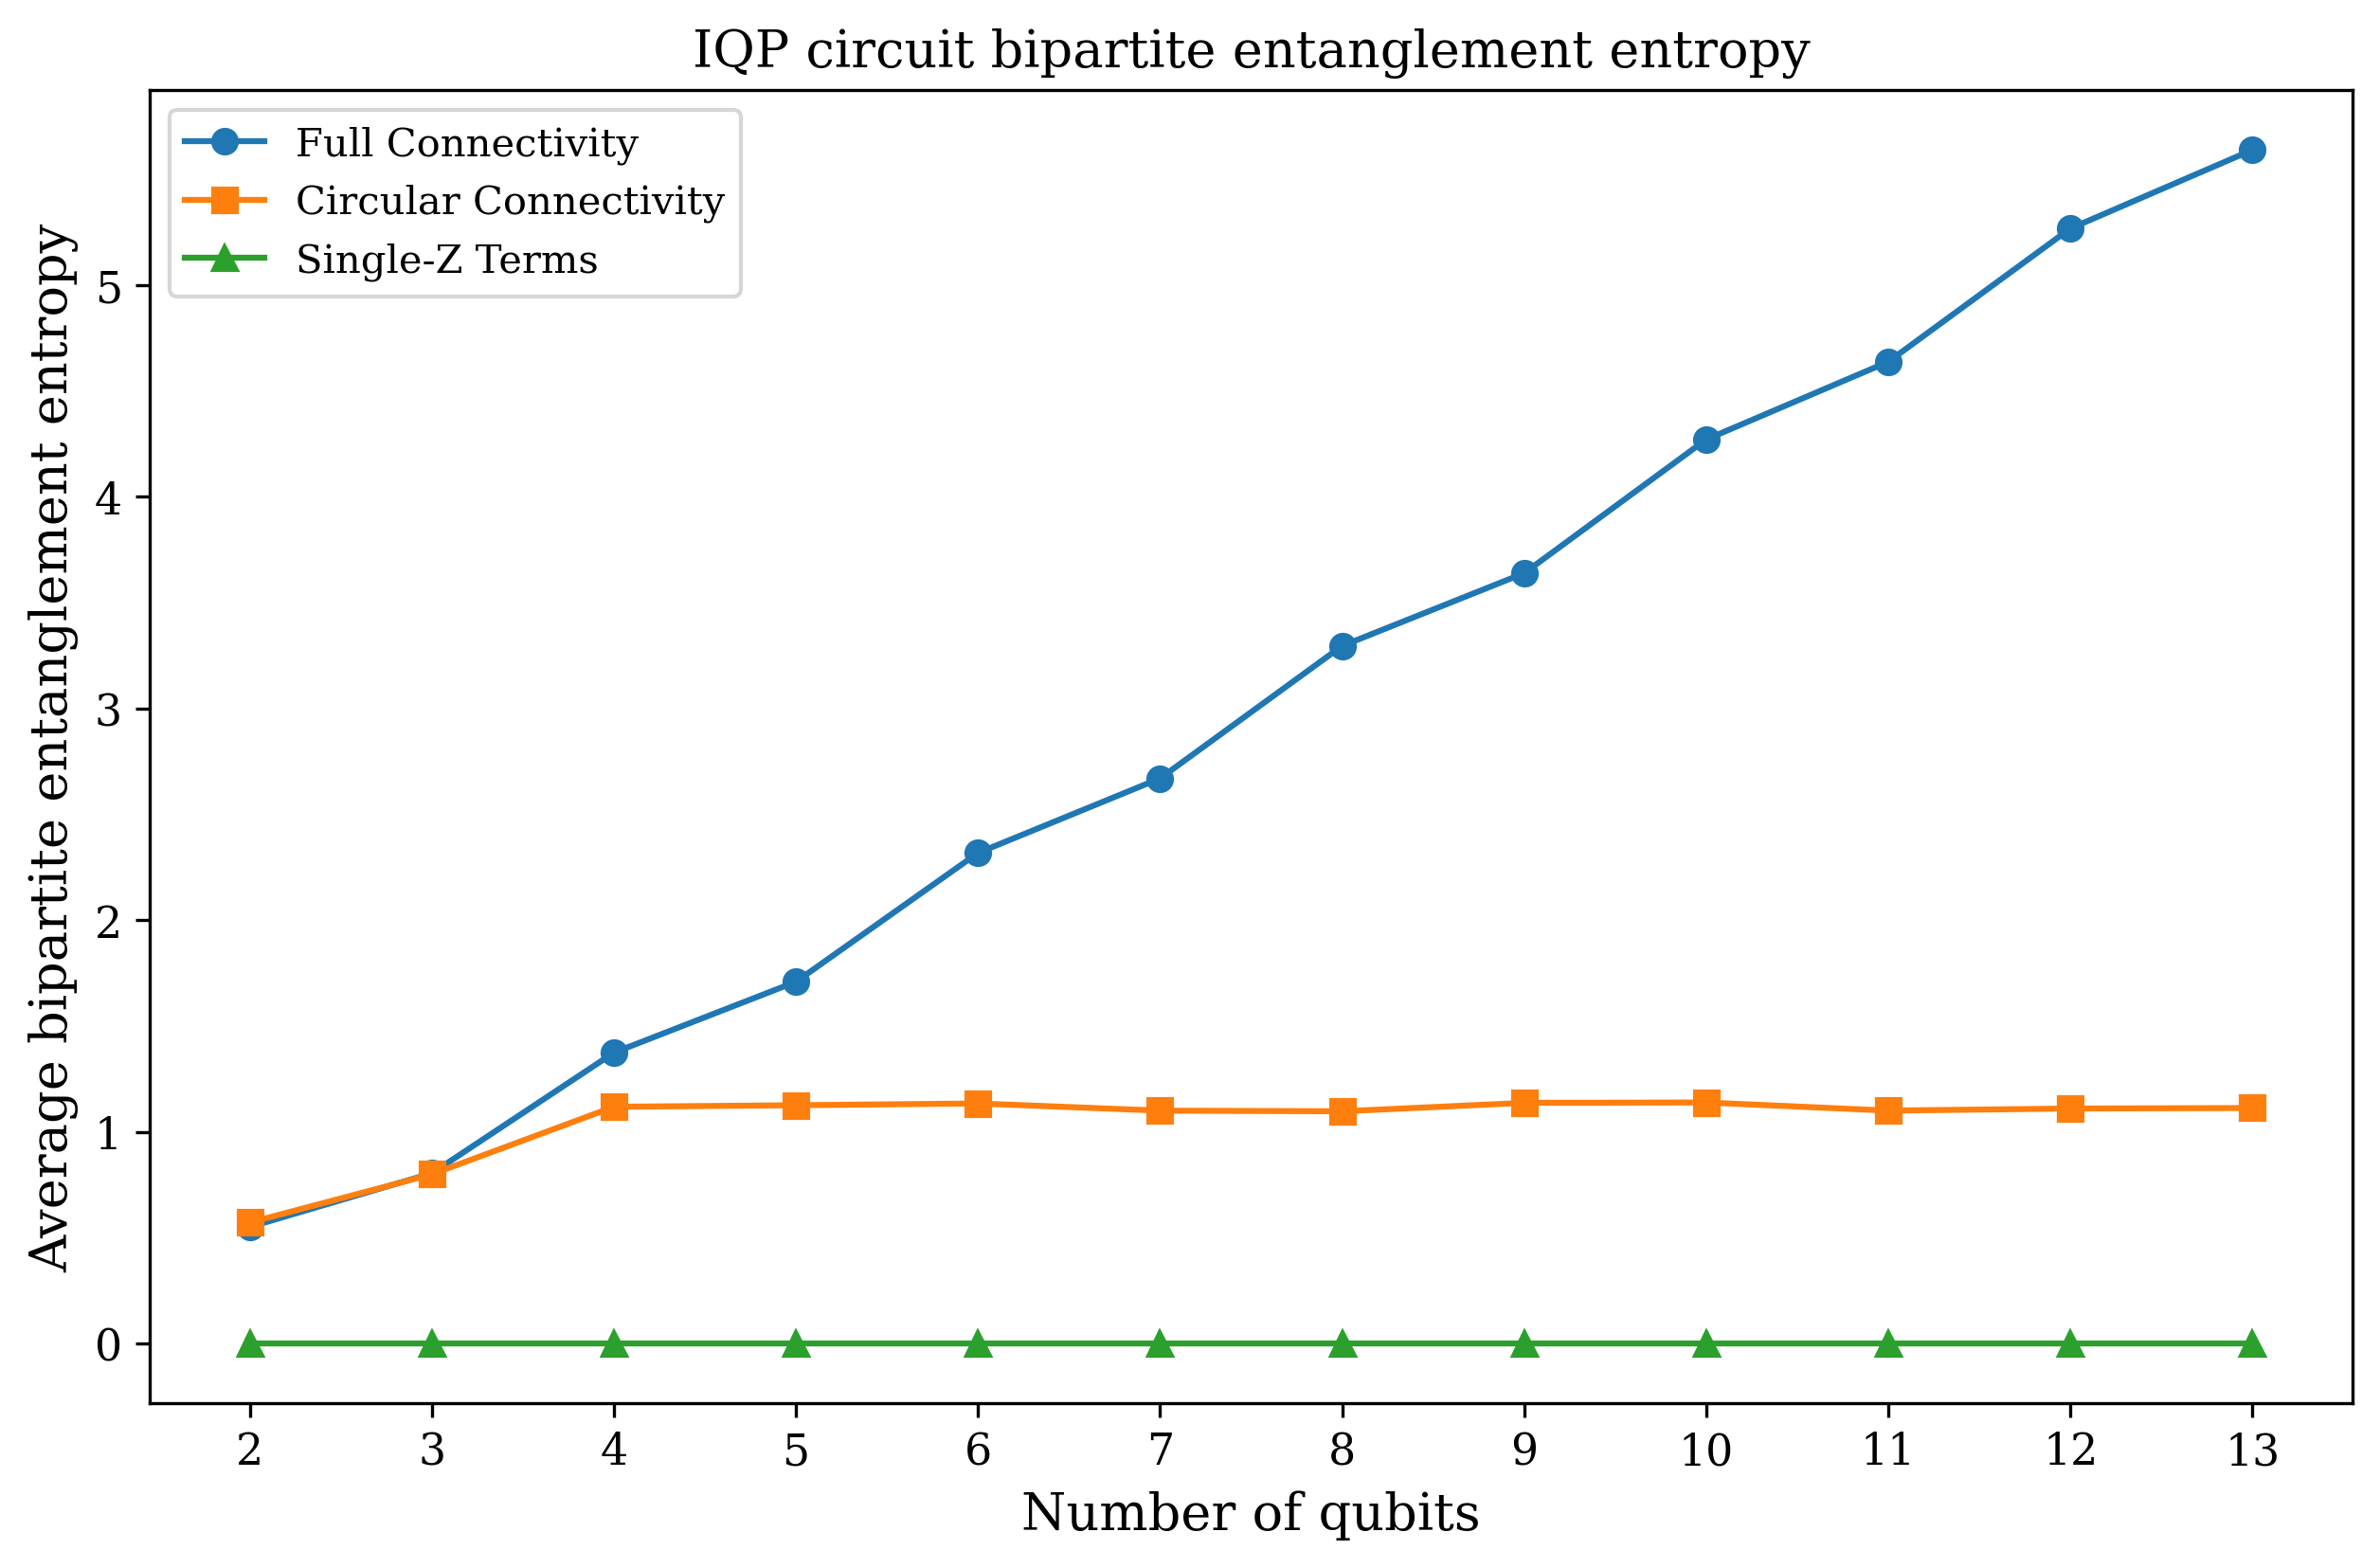

In [6]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
})

plt.figure(figsize=(10,6))

plt.plot(qubits, S_full, 'o-', label='Full Connectivity')
plt.plot(qubits, S_circular, 's-', label='Circular Connectivity')
plt.plot(qubits, S_single, '^-', label='Single-Z Terms')

plt.xlabel("Number of qubits")
plt.ylabel("Average bipartite entanglement entropy")
plt.xticks(np.arange(2, 14, 1))
plt.title('IQP circuit bipartite entanglement entropy')
plt.legend()

plt.savefig(
    "IQP_entropy.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [7]:
entropy = {
          'full': S_full,
          'circular': S_circular,
          'single': S_single
          }

In [8]:
# Save dataset to disk
with open("entropy.json", "w") as f:
    json.dump(entropy, f, indent=4)

print("Dataset saved to expressibility.json")

Dataset saved to expressibility.json


In [34]:
with open("entropy.json", "r") as f:
    entropy = json.load(f)

print("Dataset loaded successfully")

Dataset loaded successfully


In [35]:
entropy

{'full': [0.5515270936211696,
  0.8049313907323549,
  1.374563427572028,
  1.7093708524814284,
  2.3179125512138024,
  2.6699659067810475,
  3.295614463947997,
  3.6391705965301933,
  4.270556528299738,
  4.637506307707108,
  5.267000528352546,
  5.6380284926623405],
 'circular': [0.5722696774080663,
  0.8002208893251489,
  1.1190133774649331,
  1.126362773416013,
  1.1347999082126976,
  1.1008343967743803,
  1.09767850582558,
  1.1376874969527802,
  1.1393052066329878,
  1.1009859670078368,
  1.1107938157370454,
  1.1132176632028898],
 'single': [1.6085454117230772e-15,
  2.032741272830684e-15,
  5.301841750590085e-15,
  5.922283013825006e-15,
  8.609990413555373e-15,
  9.495664249092485e-15,
  1.2594784633650798e-14,
  1.3161491302004842e-14,
  1.623962572536131e-14,
  1.7015575660026772e-14,
  1.3129810183927685e-13,
  1.3367676028197233e-13]}

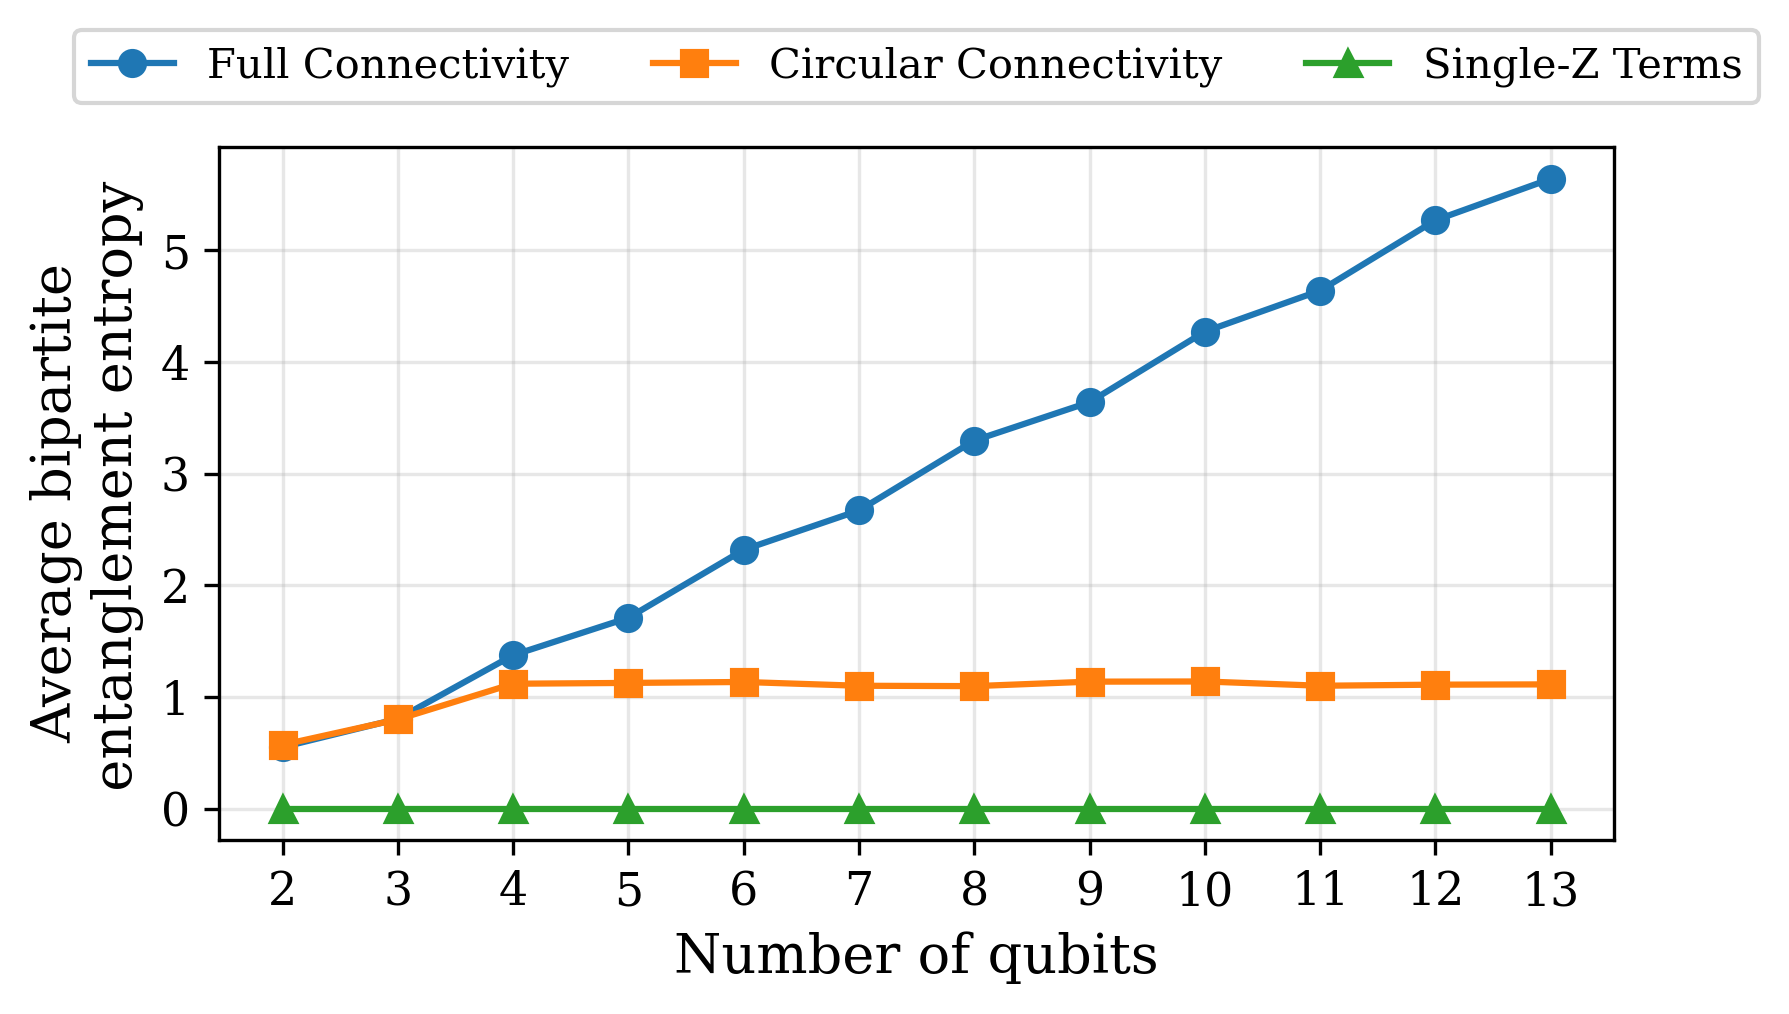

In [58]:
qubits = range(2, 14)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
})

plt.figure(figsize=(6,3))

plt.plot(qubits, entropy['full'][:len(qubits)], 'o-', label='Full Connectivity')
plt.plot(qubits, entropy['circular'][:len(qubits)], 's-', label='Circular Connectivity')
plt.plot(qubits, entropy['single'][:len(qubits)], '^-', label='Single-Z Terms')

plt.xlabel("Number of qubits")
plt.ylabel("Average bipartite \n entanglement entropy")
plt.xticks(np.arange(2, 14, 1))
# plt.title('IQP circuit bipartite entanglement entropy')
plt.grid(True, alpha=0.3)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.2),
    ncol=3,
    frameon=True
)

plt.savefig(
    "IQP_entropy.pdf",
    dpi=600,
    bbox_inches="tight"
)